<a href="https://colab.research.google.com/github/alejolion57-stack/Portafolio_Alejandro-Leon/blob/main/telecom_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
**Análisis ConnectaTel**
-
---
**El objetivo de este proyecto es evaluar el comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel, con información registrada **hasta el año 2024**.

**Para este proyecto trabajare con tres datasets:**  

1.  **plans.csv** → Contiene información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra).  
2. **users.csv** → Muestra información de los clientes (edad, ciudad, fecha de registro, plan, churn).  
3. **usage.csv** → Registra detalles del **uso real** de los servicios (llamadas y mensajes).  

---
**🛠️ Metodología:**
-
---
1. **Explorarción**, **limpieza** y **análisis** de los datos.
2. **Construcción del perfil estadístico** de los clientes.
3. **Detección** de comportamientos atípicos.
4. **Creación** de segmentos de clientes.  

Este análisis permitió **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.


---
**🔍Exploración preliminar de los datos**
--
 En esta etapa hago una validación de que los archivos carguen correctamente así cmo una vista rápida de sus columnas, tipos de datos y posibles inconsistencias.

**🛠️Paso a paso:**  
1. Importación de las librerías necesarias (`pandas`, `seaborn`, `matplotlib, numpy )

2. Carga de los archivos CSV usando:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
3. Almacenamiento de los DataFrames en las variables: `plans`, `users`, `usage`.
4. Impresión y revisión preliminar de los DF.
---

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


---
**🔍Exploración de la estructura de los datasets**
-

**🛠️ Metodología:** Revisión de la **estructura de cada dataset**, revisando cuántas filas y columnas tienen, identificando los **tipos de datos** de cada columna y detectando posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

---

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

**Identificación de problemas de calidad de datos (revisión de valores nulos)**
-
Se busca detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**🛠️Paso a paso:**  
- Conteo de valores nulos por columna para cada dataset.
- Cálculo de la proporción de nulos por columna para cada dataset.

💡**El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no se hace una exploración adicional.**

---

In [ ]:
# Cantidad de valores nulos para users
print(users.isna().sum())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [ ]:
# Proporción de valores nulos para users
print(users.isna().mean())

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# Cantidad de valores nulos para usage
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


In [ ]:
# Proporción de valores nulos para users
print(usage.isna().mean())

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


---
**💡Descubrimientos**
-

**Valores nulos`Usage`:**
- Al ver el dataset se puede ver que presenta **469 valores nulos** en la columna city con una **proporsión de 10% que podemos ignorar**  por el momento.
-  Al ver la columna **churn_date  con  3534 valores nulos** y una **proporción del 88%** podemos ver que las cancelaciones son bastante bajas lo que resulta siendo una muy buena noticia que seguiremos a lo largo del análisis para **detectar tasas de retención o posibles patrones de cancelación**.
---
**Valores nulos `Users`:**
- Se encuentran valores nulos a profundizar en las columnas: **duration 55% y length 44%** que pueden corresponder al tipo de comunicación (voz o mensaje de texto) por lo que es importante hacer un análisis más profundo que permita **imputar.** en la categoria correcta.

---

**✅ Hipótesis inical. Es un comportamiento de valores nulos normal.**



---

**❌ Detección de valores inválidos y sentinels**
-
---

In [ ]:
# explorar columnas numéricas de users
users[["user_id", "age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


---
🔍**Descubrimientos**
-
1. La columna `user_id` Está limpia y bien estructurada, sigue el patrón  y se encuentra dentro del rango esperado, lo cual es una
   **buena señal de calidad de datos**.
2. En la columna `age` tenemos un sentinel claro en la **edad mínima de - 999 años.**

In [ ]:
# explorar columnas numéricas de usage
usage[["id", "user_id", "duration", "length"]].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



---
🔍**Descubrimientos**
-

1. Los datos de las columnas `id` y `user_id` **presentan rangos confiables**  de 1 a 40,000 (id) y 10,000 a 13,999 (user_id), sin
   mayores dispersiones o outliners.  
2. La columnas'`duration`: vemos un promedio de 5.2 minutos pero un Máximo de 120 minutos. Es decir que hay usuarios con llamadas
   23 veces más largas que el promedio y esto representa  ***Outliners extremos que debemos estudiar.*** para que no afecten
   nuestras conclusiones posteriormente.
3. La columna`length` tambien muestra **Outliners extremos** con un promedio de 52 mensajes y un máximo de 1,490.

In [ ]:
# explorar columnas categóricas de users
columna_user_city = users["city"].value_counts()
columna_plan = users["plan"].value_counts()
print(columna_user_city)
print(columna_plan)

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


---
🔍**Descubrimientos**
-

- En la columna `city` encontramos un sentinel importante con **96 usuarios ("?")** que no tienen información de ciudad asignada y **deben ser reemplazados por NaN** para su correcto análisis.
- La columna `plan` no presenta **ningun problema en los datos** y se puede contunuar con sus valores para el análisis.

In [ ]:
# explorar columna categórica de usage
columna_type= usage['type'].value_counts()
print(columna_type)

text    22092
call    17908
Name: type, dtype: int64


👏**La columna `type` está bien estructurada y nos permite continuar con en análisis sin necesidad de correciones.**

---
**📅 Revisión y estandarización de fechas**
-
Antes de el análisis me aseguro  que las columnas de **fecha estén correctamente formateadas** y detectecto **años fuera de rango** que indiquen errores de captura.

---
**🛠️Paso a paso:**  
1. Convierto las columnas de fecha a tipo fecha y asegurar de que el código sea a prueba de errores.  
2. Revisión cuántas veces aparece cada año.
3. Identificación de fechas imposibles (2026).
---

In [ ]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")

#Demostración del cambio
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   float64       
 4   city        3435 non-null   object        
 5   reg_date    3960 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 250.1+ KB


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] =pd.to_datetime(usage['date'], errors="coerce")

# Demostración del cambio
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [ ]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

⚠️ En `reg_date`, Existen 40 registros con **una fecha imposible (2026)**

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

⚠️ En `date`, se puede ver que todos los datos son consistentes al 2024 y no necesitamos hacer ningun tratamiento adicional.

---

**🔍Fechas fuera de rango:**
-
Aparecen **40 registros** con fecha imposible (2026) en `users`  que se deben **reemplazar por NaN.**

---

---

**✨Limpieza básica de datos**
-

En esta sección se corrijo sentinels y fechas imposibles aplicando reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**🛠️Paso a paso:**  
1. En `age`, reemplazo el sentinel **-999** con la mediana.
2. En `city`, reemplazo el sentinel `"?"` por valores nulos.  
2. Marco como nulas las fechas fuera de rango.

---

In [ ]:
# Reemplazar -999 por la mediana de age

age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users["city"].replace("?", pd.NA)


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:

# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users["reg_date"].where(users["reg_date"].dt.year<=2024, other= pd.NaT)

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

---
**Ajuste desentinels y fechas imposibles**
-
**🛠️Paso a paso:**
Verifico si los nulos en `duration` y `length` son **MAR**(Missing at Random) revisando si dependen de la columna `type`. En caso de confirmar que son MAR **reviso las implicaciones para el análisis al déjalos como nulos.**

---

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

---
✏️**Diagnóstico :**
-
Tanto en `duration` como `length` son MAR (Missing at Random), porque su ausencia depende de la columna `type`  Imputar estos valores introduciría ruido en el análisis. Se recomienda dejarlos como NaN y filtrar por type == 'call' cuando se analice duración.

---

**👤 Agrupación por comportamiento de uso**
-

A continuación resumo las variables clave de la tabla `usage` **por usuario**, creando métricas que representen el comportamiento real de uso histórico.

**🛠️Paso a paso:**
1. Construyo una tabla agregada de `usage` por `user_id` que incluya:
- Número total de mensajes.  
- Número total de llamadas.
- Total de minutos de llamadas.

2. Renombro las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`

3. Combino esta tabla con  el Dataset`users`.

---

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({"is_text": "sum", "is_call" : "sum", "duration" : "sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes',
                                      'is_call': 'cant_llamadas', 'duration' : 'cant_minutos_llamada'})


# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


---
**Resumen estadístico por usuario durante el 2024**
-

Analizo las **columnas numéricasy categóricas de los usuarios**, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**🛠️Paso a paso**  
1. **Resumen estadístico** para las columnas numéricas relevantes.  
2. **Revisión de la distribución porentual** de cada categoría ara la columna `plan`.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

**📊Visualización de distribuciones (uso y clientes) y outliers**
-

 En este paso uso **histogramas** para: entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen **diferencias** según el tipo de plan, analizar la **forma de la distribución** y formular **insights** respecto al plan y la variable.

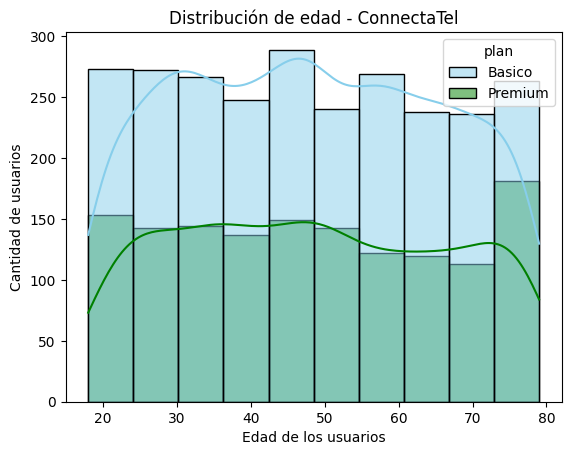

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10, hue='plan', palette=['skyblue', 'green'], kde=True)
plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de edad - ConnectaTel')
plt.show()

---
**💡Insights:**
-

**Al ver la gráfica** podemos concluir que la distribución de edad es **simétrica.**

**Rango 40–50 años:** punto de mayor uso total. Es el tramo con más usuarios combinados (~290 Básico + ~130 Premium), lo que lo convierte en el segmento más valioso en volumen.

**El plan Básico** es transversal a todas las edades y representa el 64.875% del total de usuarios. Indica que ConnectaTel atrae usuarios Básicos sin importar la edad, el producto tiene un **alcance demográfico amplio**.
**Plan Premium tiene dos segmentos etarios diferenciados:**

**1. Pico ~28–35 años (adultos jóvenes):** Posiblemente con mayor poder adquisitivo y mayor adopción tecnológica.

**2. Pico ~60–70 años (adultos mayores):** Posiblemente valoran características premium como soporte o funcionalidades adicionales.
Esto puede sugerir que el valor percibido del plan Premium es diferente para cada segmento.

**Brecha Básico vs. Premium consistente:** En todos los rangos de edad, los usuarios Básicos (~250) casi duplican a los Premium (~130–150), lo que indica un desafío de conversión parejo en todos los segmentos etarios.







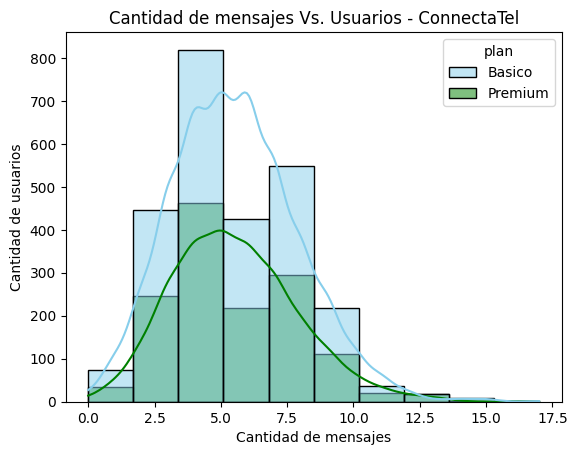

In [ ]:

# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan', palette=['skyblue', 'green'], kde=True)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de mensajes Vs. Usuarios - ConnectaTel')
plt.show()



---
**💡Insights:**
-
**Al ver la gráfica** podemos concluir que la distribución  presenta un **sesgo a la derecha.**

  
**Pico compartido en 4–5 mensajes:** Ambos segmentos coinciden en este rango como el más frecuente → este es el comportamiento "típico" del usuario ConnectaTel.

**Concentración de uso bajo:** La mayoría de usuarios (en ambos planes) envía entre 2 y 8 mensajes, lo que sugiere un uso moderado o casual de la plataforma.

**Usuarios Básicos son más numerosos:** Las barras azules superan ampliamente a las verdes (~800 vs ~450 en el pico), indicando que el plan Básico tiene mayor base de usuarios.

**Comportamiento más predecible en Premium** La distribución Premium es más concentrada y simétrica lo que nos muestra que los usuarios Premium tienen un patrón de uso más consistente y regular.

**Cola larga en usuarios Básicos:** Hay usuarios Básicos que llegan a 15–17 mensajes, lo que podría representar oportunidades de conversión a Premium (usuarios que ya usan mucho el servicio pero no han migrado de plan).


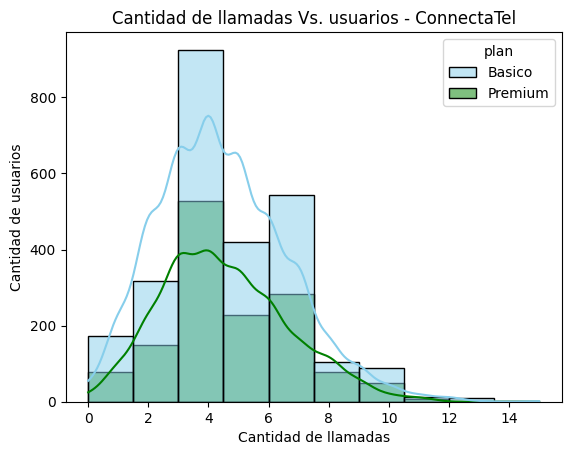

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan', palette=['skyblue', 'green'], kde=True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de llamadas Vs. usuarios - ConnectaTel')
plt.show()

---
**💡Insights:**
-
**Al ver la gráfica** podemos concluir que la distribución presenta un **sesgo a la derecha.**


**Comportamiento muy similar al de mensajes:** La mayoría de usuarios se concentra en un uso moderado-bajo (3–7 llamadas), con pocos usuarios haciendo muchas llamadas ~12.

**Gran pico en 3–4 llamadas para usuarios Básicos:** Con casi 900 usuarios, este es el valor  más alto visto en los tres análisis. Los usuarios Básicos tienen un comportamiento muy concentrado en ese rango.

**Segunda barra alta en 6–7 llamadas:** Ambos planes muestran un segundo repunte en ese rango (~540 Básico, ~300 Premium), lo que podría indicar un subgrupo de usuarios con mayor engagement.

**Usuarios con 0 llamadas son relevantes:** Hay ~175 usuarios Básicos y ~75 Premium con cero llamadas. Esto puede indicar:
   1. Usuarios inactivos o en riesgo de irse.
   2. Usuarios que prefieren mensajes sobre llamadas (cruzando con el análisis anterior).

**Cola derecha más pronunciada en Básico:** Hay usuarios Básicos con hasta 14–15 llamadas, mientras que Premium rara vez supera las 10–11. Esto puede sugerir que usuarios de alto consumo no están migrando a Premium pese a su uso intensivo.


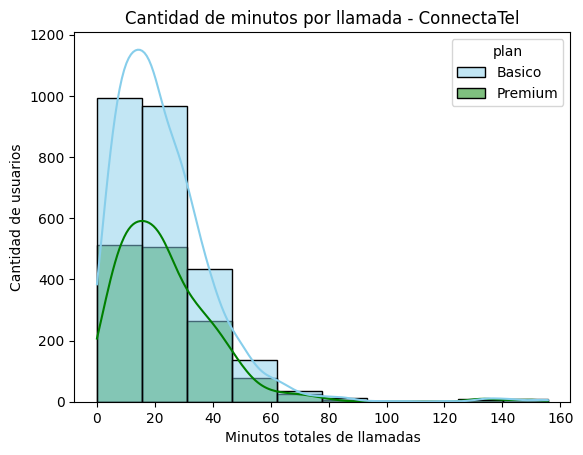

In [ ]:

# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan', palette=['skyblue', 'green'], kde=True)
plt.xlabel('Minutos totales de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de minutos por llamada - ConnectaTel')
plt.show()

---
**💡Insights:**
-
**La grafica muestra un fuerte sesgo a la derecha**

**La mayoría de usuarios hace llamadas muy cortas:** Tanto Básico como Premium se concentran en 0–20 minutos totales, lo que indica que el uso de llamadas es generalmente breve o esporádico.

**Básico tiene el pico más extremo de todos los análisis:** ~1000 usuarios Básicos en el primer rango (0–20 min) es el valor más alto registrado en las 4 gráficas. Esto refuerza que los usuarios Básicos son llamadores de baja duración.

**Premium se desplaza ligeramente hacia la derecha:** El pico Premium (~10–20 min) está levemente más a la derecha que el de Básico (~0–10 min), lo que sugiere que los usuarios Premium hacen llamadas un poco más largas, posiblemente por tener beneficios de mayor duración incluidos en su plan.

**Cola larga y pesada en Básico:** Los suarios Básicos llegan hasta 140–160 minutos, muy por encima del Premium (~80–90 min). Esto puede indicar usuarios de alto consumo que aún no han migrado al plan adecuado.

**El sesgo más pronunciado de los 4 análisis:** Esta distribución es la más asimétrica de todas, con una diferencia enorme entre la moda (0–20 min) y los valores extremos (160 min). .

**Pocos usuarios "heavy users":** A partir de los 80 minutos, ambas curvas casi tocan cero, indicando que los usuarios de alto consumo son una minoría, pero probablemente de alto valor estratégico.

---
**📈Revisión de límites mínimo y máximo**
-
---

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


---
**💡Insights:**
-

***Cant_mensajes:***
   ***Mantener los outliers:** Media: 5.52 | Máx: 17
El valor máximo de 17 mensajes no está lejos del rango intercuartílico. La diferencia entre Q75 (7) y el máx (17) no es extrema.
En telecomunicaciones, un usuario con 17 mensajes es perfectamente plausible.


***cant_llamadas:***
  ***Mantener los outliers:*** Media: 4.48 | Máx: 15
Similar razonamiento: 15 llamadas es un valor alto pero realista para un usuario frecuente.
La distribución parece razonablemente simétrica (media 4.48 Vs. mediana 4.0), lo que sugiere que los outliers no distorsionan severamente.


***cant_minutos_llamada:*** Media: 23.32 | Máx: 155.69 | Q75: 31.42
**Se puede evaluar con más cudado o hacer una Winsorización pero se puede mantener
Aquí hay una diferencia notable: el máximo 155.69 yel Q75 31.42, lo que indica outliers más extremos.
Sin embargo, en datos de telecomunicaciones, usuarios con llamadas muy largas son reales (soporte técnico, usuarios corporativos, etc.).

---

**📱Segmentación de clientes por uso**
-

 En esta etapa inicial de segmentación clasifico cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándome en la cantidad de llamadas y mensajes registrados.

**🛠️Paso a paso:**  
1. Creo una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
2. Uso comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigno:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

---

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'Uso medio',
        'Alto uso'
    )
)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


---
**🚸 Segmentación de clientes por edad**
-
Ahora clasifico a cada usuario en un grupo por **edad** para obtener una información m´s profunda que permita perlfilar detalladamente a cada segmento de usarios.

**🛠️Paso a paso:**  
1. Creo una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
2. Uso comparaciones lógicas (<, >) para evaluar las condiciones y asigno:
  - `'Joven'` cuando age < 30.
  - `'Adulto'` cuando age < 60.
  - `'Adulto Mayor'` para el resto de casos.

---

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 'Joven',
    np.where(
        user_profile['age'] < 60, 'Adulto',
        'Adulto Mayor'
    )
)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


---
**📈Visualización de la Segmentación de Clientes**
-

---

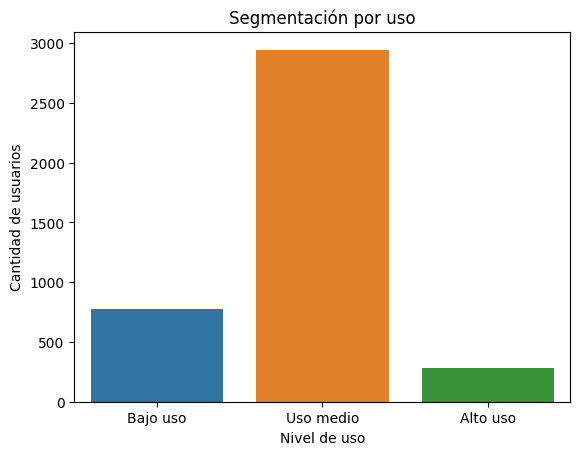

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Segmentación por uso')
plt.xlabel('Nivel de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

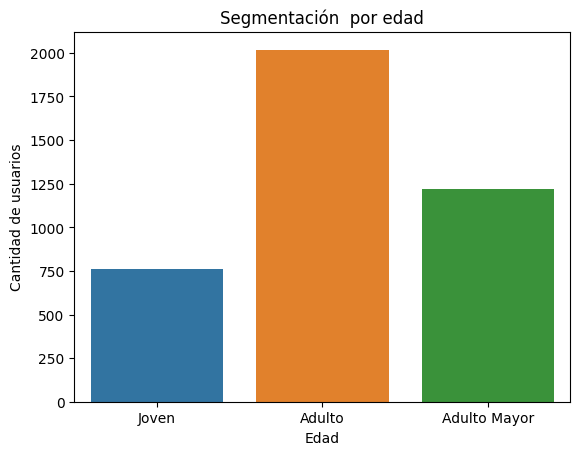

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Segmentación  por edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

---
**📈Insight Ejecutivo para Stakeholders**
-
---
⚠️ **Problemas detectados en los datos:**
-

1. **Sentinel en age:** 1 registro con valor -999 (~0.03% del total). Se reemplazó por la mediana para no distorsionar la
   distribución de edad.
2. **Sentinel en city:** 96 registros con valor "?" (~2.4% de usuarios). Se reemplazaron por NaN ya que no representan una ciudad
   válida.
3. **Fechas imposibles en reg_date:** 40 registros con año 2026 (~1% del dataset). Se marcaron como NaT al ser fechas fuera del
   rango de datos registrados hasta 2024.
4. **Valores nulos MAR en duration y length:** 55% y 44% respectivamente, pero su ausencia depende del tipo de comunicación (call
   vs text). Se dejaron como NaN para no introducir ruido al análisis.

---
**🚸 Segmentos por edad**

- **Jóvenes (< 30 años):** Minoría del base de usuarios. Muestran un pico notable en adopción del plan Premium, posiblemente por mayor afinidad tecnológica y mayor poder adquisitivo relativo a su etapa de vida.

- **Adultos (30–59 años):** Segmento más numeroso, especialmente el rango 40–50 años que concentra el mayor volumen combinado (~420 usuarios). La mayoría opta por el plan Básico, representando la mayor oportunidad de conversión a Premium.

- **Adultos Mayores (60+):** Segundo pico de adopción Premium. Este grupo valora posiblemente beneficios de atención o funcionalidades adicionales. Son un segmento fiel y con potencial de alto valor de vida (LTV).

---
**📱Segmentos por nivel de uso**

- **Bajo uso (llamadas < 5 y mensajes < 5):** Segmento mayoritario. Usuarios con comportamiento esporádico o casual. Alta proporción en plan Básico. Riesgo de churn si no encuentran valor en el servicio.

- **Uso medio (llamadas < 10 y mensajes < 10):** Segmento intermedio con comportamiento más estable. Candidatos naturales para migración a Premium si se les ofrece un incentivo claro.

- **Alto uso (resto):** Minoría del total, pero con mayor impacto en ingresos. Incluye usuarios con hasta 15 llamadas y 17 mensajes, y minutos de llamada de hasta 155 min. Muchos permanecen en plan Básico pese a su consumo intensivo.

---
**💡En conclusión**
-
ConnectaTel tiene una base de clientes amplia y diversa, pero concentrada en uso bajo-moderado y plan Básico. Existe una brecha clara entre el comportamiento real de consumo y el plan contratado: usuarios de alto uso que no han migrado a Premium representan tanto una pérdida de ingreso potencial como un riesgo de insatisfacción si exceden los límites del plan. La distribución de edad simétrica indica que **el producto tiene alcance demográfico amplio**, lo que facilita **estrategias de segmentación diferenciadas por grupo etario**.


---
🎯**Recomendaciones**
-
1. **Campaña de conversión a Premium para adultos de 40–50 años con uso medio-alto:** Es el segmento con mayor volumen y consumo real. Se pueden implementar diferente estrategias de migraciós como: Un descuento en Premium por 6 meses o incluso prueba gratuita.

2. **Plan intermedio o "Plus":** La brecha entre Básico y Premium puede estar frenando conversiones por eso es importante desarrollar **un plan con límites moderados a precio intermedio** que captaría al segmento de uso medio.

3. **Programa de retención para usuarios de bajo uso:** Usuarios con 0–3 llamadas y mensajes son los más propensos a cambiar de operador. Para ellos podríamos hacer notificaciones presentando los beneficios no utilizados tipo **"Sabías que tu plan es más de lo que piensas..."** o bonificaciones por actividad para reactivarlos.

4. **Estrategia diferenciada para Adultos Mayores Premium:** Dado su patrón de uso y fidelidad, vale la pena diseñar beneficios específicos como una actualización de su plan al **"Paquete Silver":** soporte prioritario en los canales de atención, 2 familiares incluidos.

5. **Monitoreo de "heavy users" en plan Básico:** Los usuarios en la cola derecha de minutos (>80 min) y llamadas (>10) son candidatos de alto valor para Premium pero pueden sentirse engañados si ven que por su volumen de uso podía ya serlo. Es sumamente importante hacer una campaña flash con oferta de upgrade automático que pueda aumentar conversiones sin fricción.

**Contacto**
-
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Alejandro%20León-0077B5?style=for-the-badge&logo=linkedin&logoColor=1E293B)](https://www.linkedin.com/in/alejandrole%C3%B3nospina/)
[![Email](https://img.shields.io/badge/Email-alejolion57%40gmail.com-D14836?style=for-the-badge&logo=gmail&logoColor=white)](mailto:alejolion57@gmail.com)
[![GitHub](https://img.shields.io/badge/GitHub-Portafolio-181717?style=for-the-badge&logo=github&logoColor=white)](https://github.com/alejolion57-stack)